In [1]:
import kagglehub
import os

import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score

In [2]:
path = kagglehub.dataset_download("harshadapatil31/student-performance-and-study-habits-dataset")
df = pd.read_csv(os.path.join(path, 'student_performance_dataset.csv'))

Using Colab cache for faster access to the 'student-performance-and-study-habits-dataset' dataset.


In [3]:
df.shape

(1000, 12)

In [4]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [5]:
df.columns

Index(['student_id', 'gender', 'study_time_hours', 'attendance_percent',
       'sleep_hours', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'previous_grade',
       'final_exam_score', 'final_grade'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [7]:
((df.isnull().sum() / len(df)) * 100)[df.isnull().sum()>0]

,0
parental_education,10.2


In [8]:
df['parental_education'] = df['parental_education'].fillna(df['parental_education'].mode()[0])

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop(["student_id","final_grade"], axis=1)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
study_time_hours,1000.0,3.5707,1.478559,0.5,2.600,3.6,4.500,8.1
attendance_percent,1000.0,85.0923,9.270685,54.8,78.800,85.2,91.900,100.0
sleep_hours,1000.0,6.7995,1.203527,3.2,5.900,6.8,7.600,10.0
previous_grade,1000.0,69.7409,12.613425,31.3,61.000,69.6,78.400,100.0
final_exam_score,1000.0,83.5435,10.341333,46.8,76.075,83.8,91.525,100.0


In [12]:
df.describe(include="object").T

,count,unique,top,freq
gender,1000,2,Female,510
parental_education,1000,4,High School,458
internet_access,1000,2,Yes,854
extracurricular_activities,1000,2,Yes,572
part_time_job,1000,2,No,684


In [13]:
n_cols = df.select_dtypes(include=["int64", "float64"])
c_cols = df.select_dtypes(include="object")

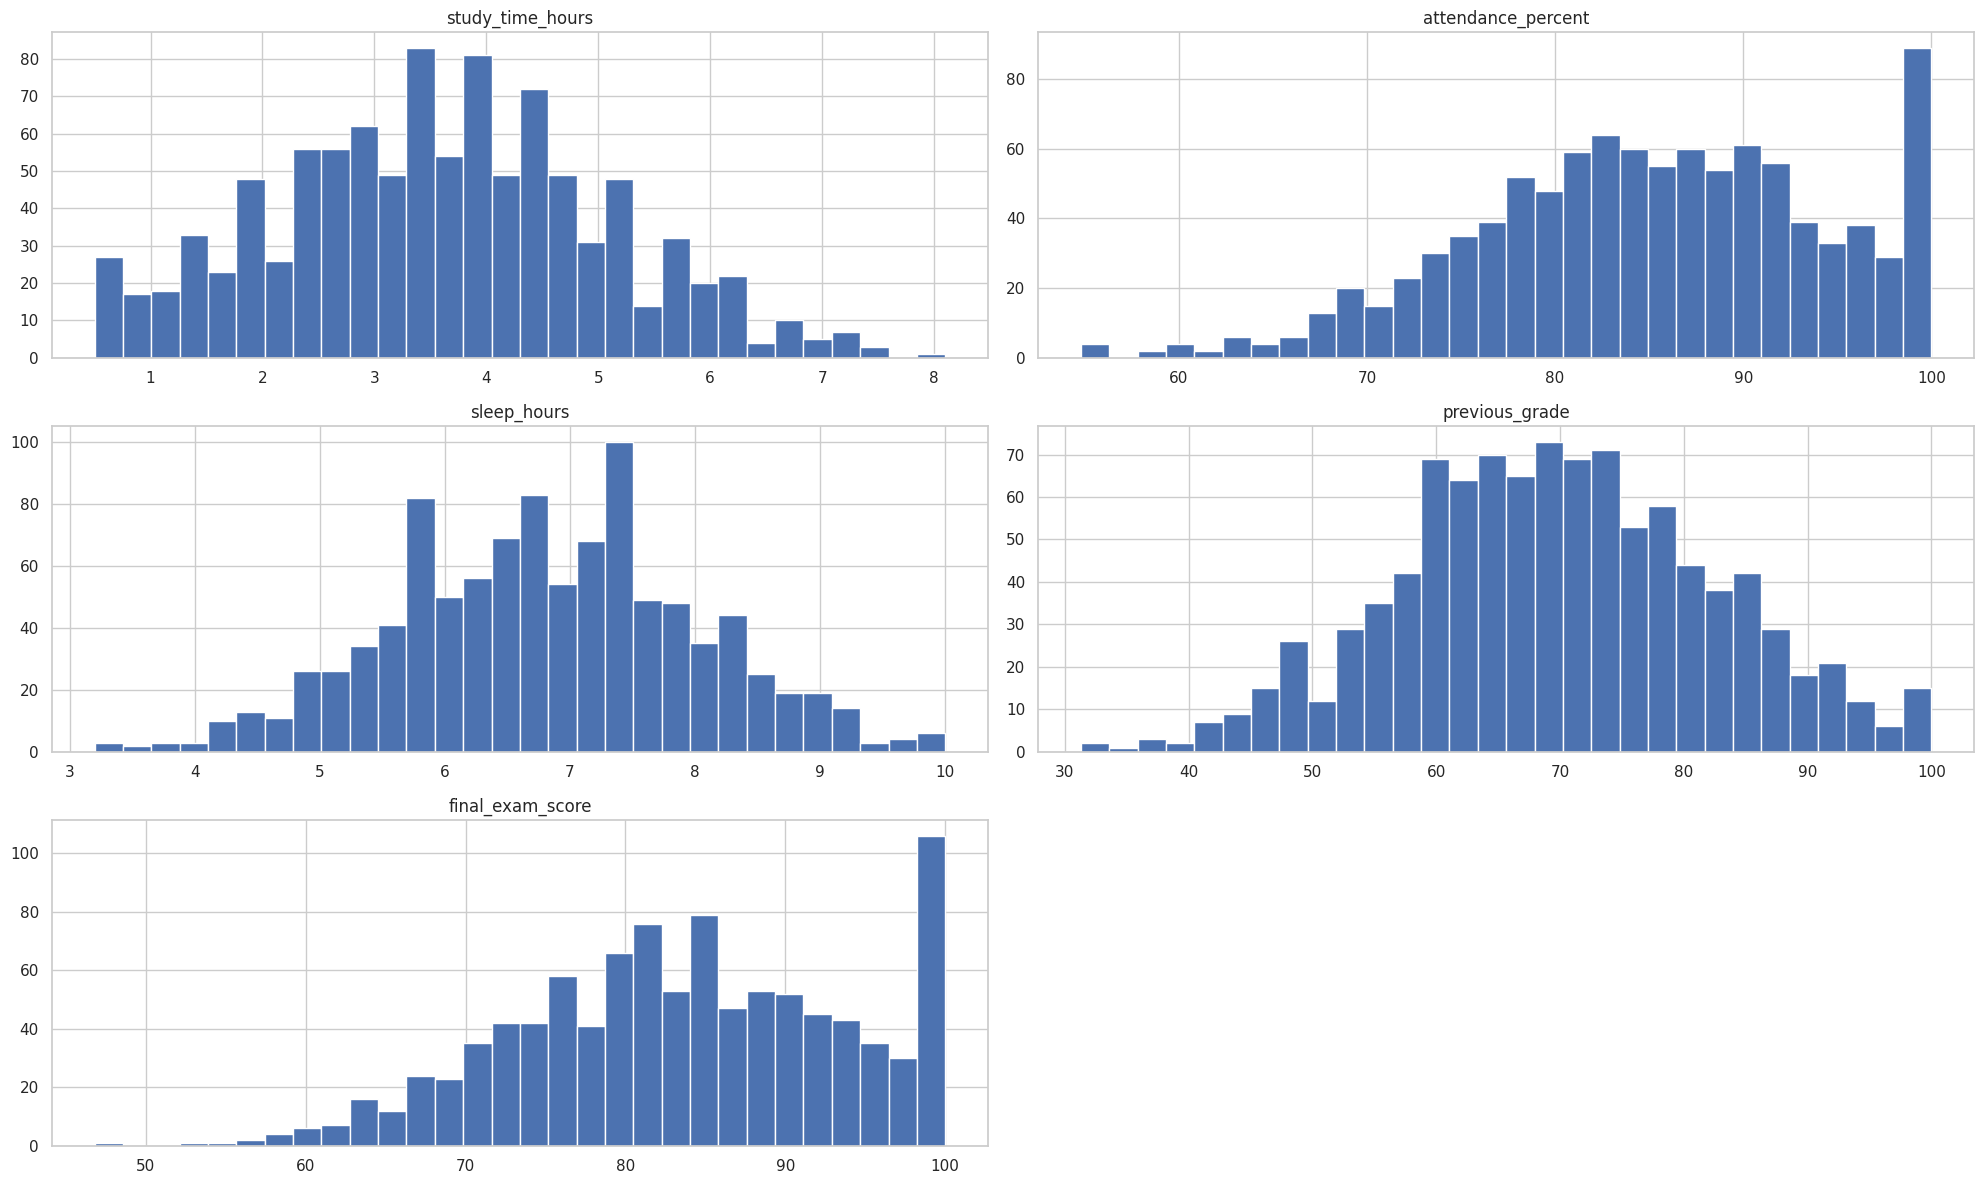

In [14]:
n_cols.hist(
    figsize=(20, 12),
    bins=30
)

plt.tight_layout()
plt.show()

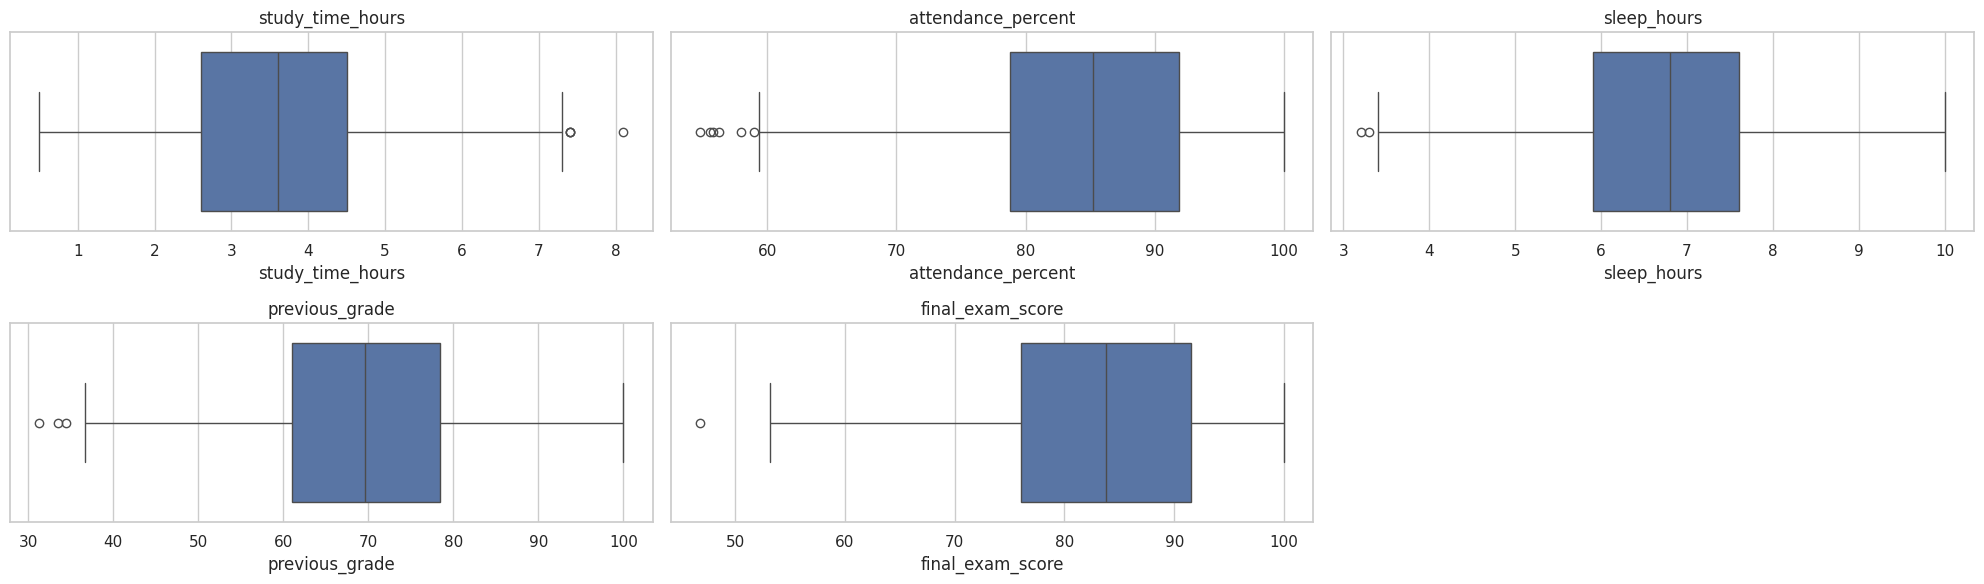

In [15]:
num_cols = n_cols.columns

c = 3
r = math.ceil(len(num_cols) / c)

fig, axes = plt.subplots(r, c, figsize=(20, 3 * r))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

for ax in axes[len(num_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

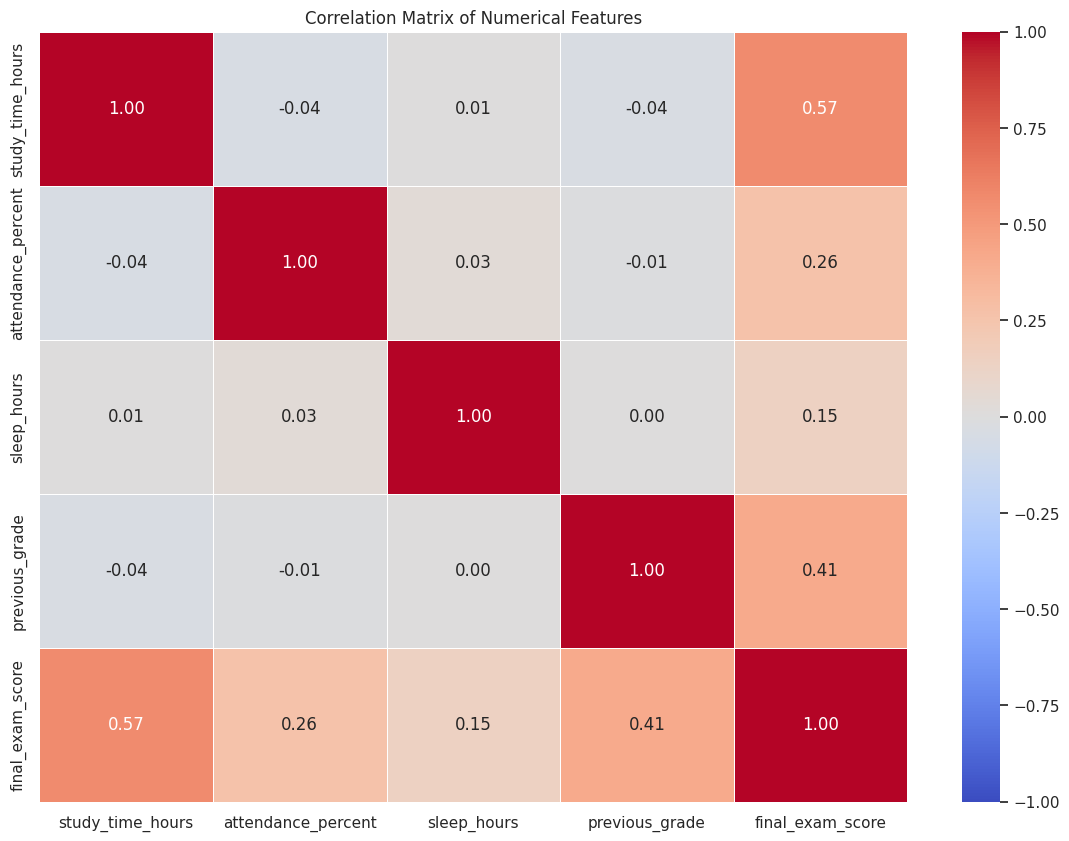

In [16]:
corr = n_cols.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

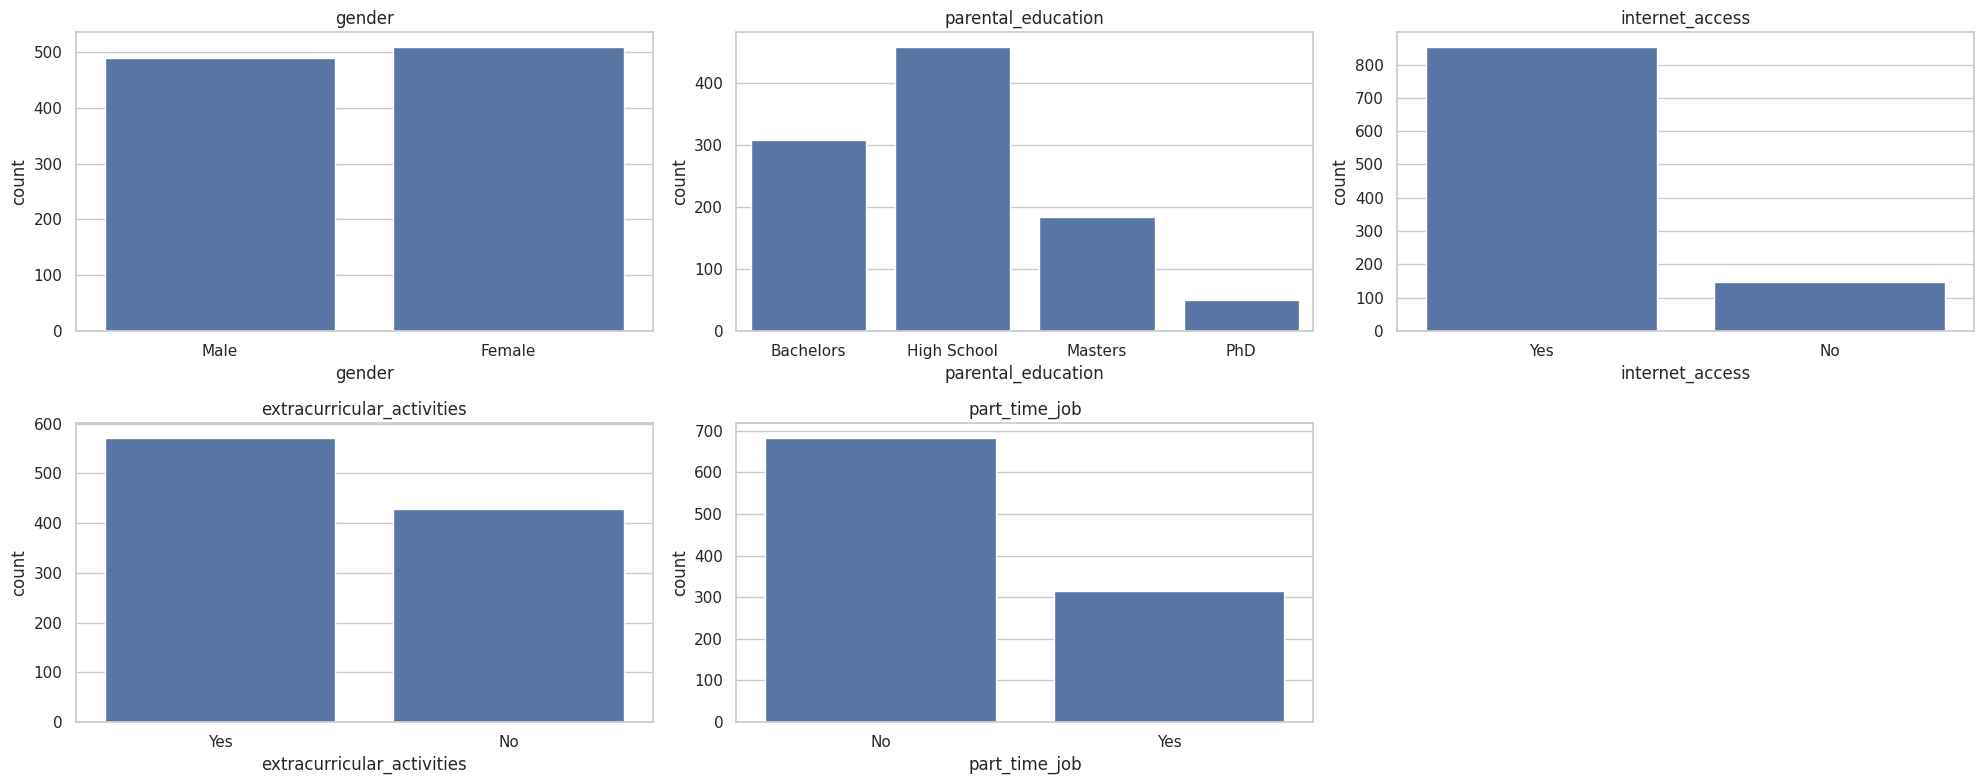

In [17]:
cat_cols = c_cols.columns

c = 3
r = math.ceil(len(cat_cols) / c)

fig, axes = plt.subplots(r, c, figsize=(20, 4 * r))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)

for ax in axes[len(cat_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

In [18]:
df_encoded = pd.get_dummies(df,drop_first=True)

In [19]:
df_encoded.head()

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score,gender_Male,parental_education_High School,parental_education_Masters,parental_education_PhD,internet_access_Yes,extracurricular_activities_Yes,part_time_job_Yes
0,4.0,98.0,6.5,76.9,100.0,True,False,False,False,True,True,False
1,6.3,100.0,5.7,75.5,100.0,False,True,False,False,True,True,True
2,4.9,85.3,7.9,88.5,97.3,True,False,False,False,True,False,True
3,2.6,77.5,8.0,85.1,83.8,True,True,False,False,True,True,False
4,2.2,89.6,4.6,61.8,68.3,True,False,False,False,True,False,True


In [20]:
df.shape

(1000, 10)

In [21]:
df_encoded.shape

(1000, 12)

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

# K-Means Clustering without PCA

k=2: 0.104
k=3: 0.112
k=4: 0.127
k=5: 0.122
k=6: 0.126
k=7: 0.119
k=8: 0.120
k=9: 0.123
k=10: 0.119


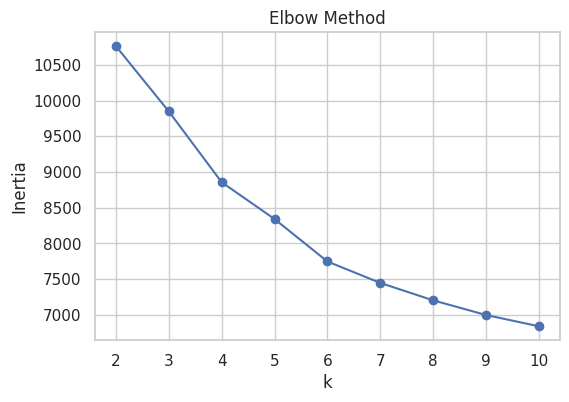

In [23]:
inertia = []
scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)

    score = silhouette_score(X_scaled, labels)
    scores.append(score)

    print(f"k={k}: {score:.3f}")

plt.figure(figsize=(6,4))

plt.plot(range(2,11), inertia, marker='o')

plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [24]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df_encoded['Cluster'] = clusters

In [25]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.12684883715739367


In [26]:
df_encoded['Cluster'].value_counts().sort_index()

,count
Cluster,
0,184
1,50
2,378
3,388


In [27]:
summary = df_encoded.groupby('Cluster').mean().round(2)
summary

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score,gender_Male,parental_education_High School,parental_education_Masters,parental_education_PhD,internet_access_Yes,extracurricular_activities_Yes,part_time_job_Yes
Cluster,,,,,,,,,,,,
0,3.60,85.04,6.82,69.34,84.03,0.47,0.00,1.0,0.0,0.87,0.61,0.34
1,3.81,85.78,6.79,69.24,85.06,0.48,0.00,0.0,1.0,0.86,0.50,0.30
2,4.35,86.35,6.92,75.45,91.41,0.49,0.57,0.0,0.0,0.91,0.60,0.27
3,2.77,83.80,6.67,64.43,75.46,0.51,0.62,0.0,0.0,0.79,0.54,0.35


### Cluster 0 – Consistent High Performers

* Achieved strong final exam scores (**84.03**).
* Maintained good attendance (**85.04%**) and balanced sleep habits (**6.82 hours**).
* Most students come from families with a **Master’s degree** background.
* High participation in extracurricular activities (**61%**).

**Insight:**
Students in Cluster 0 demonstrate consistent academic success supported by good attendance, healthy sleep patterns, strong parental educational backgrounds, and active involvement in extracurricular activities.

---

### Cluster 1 – Academically Supported Students

* Earned good final exam scores (**85.06**).
* Maintained good attendance (**85.78%**).
* Most students have parents with a **PhD** degree.
* Moderate study time (**3.81 hours**) and extracurricular participation (**50%**).

**Insight:**
Students in Cluster 1 achieve strong academic outcomes despite moderate study time, suggesting that a highly educated family environment may contribute positively to their performance.

---

### Cluster 2 – Top Achievers

* Highest study time (**4.35 hours**).
* Highest attendance rate (**86.35%**).
* Highest previous grades (**75.45**) and final exam scores (**91.41**).
* Highest internet access rate (**91%**).
* Well-balanced sleep schedule (**6.92 hours**).

**Insight:**
Cluster 2 represents the highest-performing students, characterized by strong study habits, excellent attendance, consistent academic achievement, and good access to educational resources.

---

### Cluster 3 – Students Needing Additional Support

* Lowest study time (**2.77 hours**).
* Lowest attendance (**83.80%**).
* Lowest previous grades (**64.43**) and final exam scores (**75.46**).
* Lowest internet access rate (**79%**).
* Highest proportion of students with part-time jobs (**35%**).

**Insight:**
Students in Cluster 3 show comparatively weaker academic performance, which may be associated with lower study time, reduced attendance, limited access to resources, and additional responsibilities such as part-time employment.


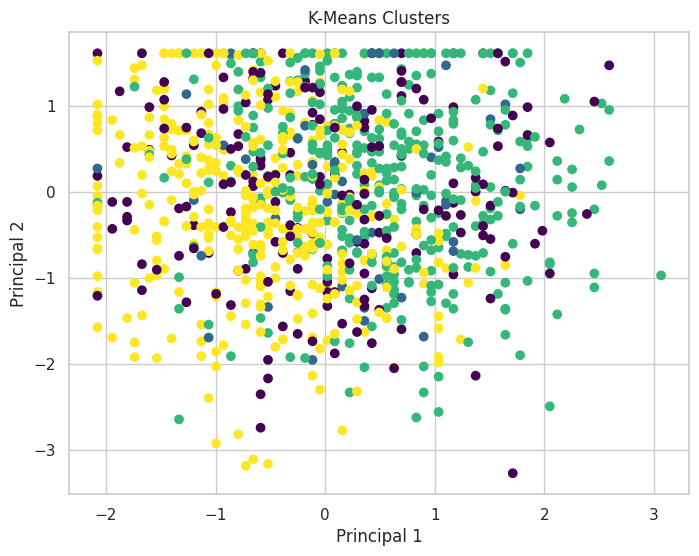

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0],X_scaled[:, 1], c=clusters, cmap="viridis")

plt.title("K-Means Clusters")
plt.xlabel("Principal 1")
plt.ylabel("Principal 2")
plt.show()

# K-Means Clustering with PCA

In [30]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

print(X_pca2.shape)
print("Explained Variance Ratio:", pca2.explained_variance_ratio_)
print("Total Explained Variance:", pca2.explained_variance_ratio_.sum())

(1000, 2)
Explained Variance Ratio: [0.14803698 0.12136117]
Total Explained Variance: 0.26939814707826815


k=2: 0.334
k=3: 0.378
k=4: 0.391
k=5: 0.424
k=6: 0.438
k=7: 0.453
k=8: 0.473
k=9: 0.466
k=10: 0.470


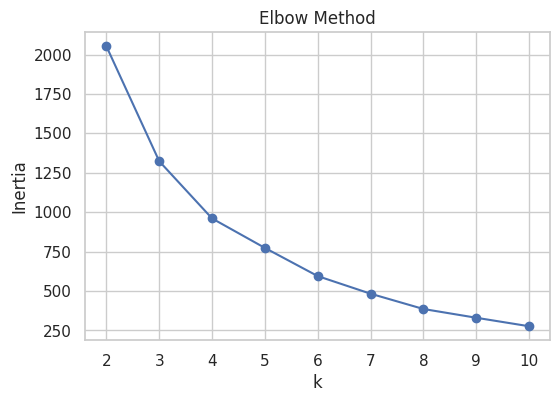

In [31]:
inertia = []
scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca2)

    inertia.append(kmeans.inertia_)

    score = silhouette_score(X_pca2, labels)
    scores.append(score)

    print(f"k={k}: {score:.3f}")

plt.figure(figsize=(6,4))

plt.plot(range(2,11), inertia, marker='o')

plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [32]:
kmeans = KMeans(n_clusters=8, random_state=42)
clusters2 = kmeans.fit_predict(X_pca2)
df_encoded['Cluster PCA'] = clusters2

In [33]:
score = silhouette_score(X_pca2, clusters2)
print("Silhouette Score:", score)

Silhouette Score: 0.4670082635487731


In [34]:
df_encoded['Cluster PCA'].value_counts().sort_index()

,count
Cluster PCA,
0,105
1,170
2,99
3,203
4,75
5,104
6,151
7,93


In [35]:
summary = df_encoded.groupby('Cluster PCA').mean().round(2)
summary

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score,gender_Male,parental_education_High School,parental_education_Masters,parental_education_PhD,internet_access_Yes,extracurricular_activities_Yes,part_time_job_Yes,Cluster
Cluster PCA,,,,,,,,,,,,,
0,4.22,87.59,7.03,71.43,89.52,0.46,0.0,0.97,0.03,0.88,0.66,0.35,0.03
1,3.51,85.19,6.70,70.73,84.28,0.48,0.0,0.00,0.10,0.85,0.52,0.25,2.25
2,5.01,87.71,7.26,77.77,96.49,0.57,0.0,0.10,0.20,0.95,0.58,0.19,1.60
3,3.33,84.56,6.82,69.03,81.88,0.50,1.0,0.00,0.00,0.88,0.51,0.34,2.68
4,2.52,81.54,6.39,63.10,73.73,0.49,0.0,0.96,0.04,0.81,0.61,0.37,0.04
5,2.26,82.38,6.64,62.62,69.62,0.50,1.0,0.00,0.00,0.73,0.56,0.44,3.00
6,4.65,88.07,7.00,76.11,94.56,0.44,1.0,0.00,0.00,0.89,0.60,0.23,2.00
7,2.50,81.54,6.38,61.99,70.90,0.51,0.0,0.00,0.08,0.77,0.63,0.42,2.85


### Cluster 0 – Strong Academic Performers

* High study time (**4.22 hours**) and attendance (**87.59%**).
* Strong final exam performance (**89.52**).
* Most students come from families with a **Master’s degree** (**97%**).
* High participation in extracurricular activities (**66%**).
* Good internet access (**88%**).

**Insight:**
Students in Cluster 0 demonstrate strong academic performance supported by consistent study habits, high attendance, active extracurricular involvement, and highly educated parents.

---

### Cluster 1 – Average Performers

* Moderate study time (**3.51 hours**) and attendance (**85.19%**).
* Good final exam scores (**84.28**).
* Lower rates of advanced parental education.
* Moderate extracurricular participation (**52%**).

**Insight:**
Cluster 1 represents average-performing students who maintain reasonable study habits and attendance, resulting in stable academic outcomes.

---

### Cluster 2 – Exceptional Achievers

* Highest study time (**5.01 hours**).
* Highest attendance (**87.71%**).
* Highest previous grades (**77.77**) and final exam scores (**96.49**).
* Highest internet access rate (**95%**).
* Lowest proportion of part-time jobs (**19%**).

**Insight:**
Cluster 2 consists of the highest-achieving students, characterized by excellent study habits, outstanding attendance, strong academic history, and access to learning resources.

---

### Cluster 3 – Moderately Performing Students

* Moderate study time (**3.33 hours**) and attendance (**84.56%**).
* Final exam score of (**81.88**).
* Most students come from families with a **High School** educational background.
* Average participation in extracurricular activities (**51%**).

**Insight:**
Students in Cluster 3 achieve moderate academic results, with performance likely influenced by average engagement levels and lower parental educational attainment.

---

### Cluster 4 – Underperforming Students

* Low study time (**2.52 hours**).
* Low attendance (**81.54%**).
* Low previous grades (**63.10**) and final exam scores (**73.73**).
* Most students come from families with a **Master’s degree** background (**96%**).
* Highest part-time job participation among the lower-performing groups (**37%**).

**Insight:**
Despite having highly educated parents, students in Cluster 4 show relatively weak academic performance, suggesting that limited study time and attendance may have a stronger impact on outcomes.

---

### Cluster 5 – At-Risk Students

* Lowest study time (**2.26 hours**).
* Low attendance (**82.38%**).
* Lowest final exam score (**69.62**).
* Highest rate of part-time employment (**44%**).
* Lowest internet access (**73%**).

**Insight:**
Cluster 5 represents the most academically vulnerable students, characterized by limited study time, lower attendance, fewer learning resources, and greater work commitments outside school.

---

### Cluster 6 – High Achievers with Efficient Learning Habits

* High study time (**4.65 hours**) and attendance (**88.07%**).
* Very strong final exam performance (**94.56**).
* Strong previous grades (**76.11**).
* Low part-time job participation (**23%**).

**Insight:**
Students in Cluster 6 achieve excellent academic results through strong engagement, high attendance, and consistent academic performance.

---

### Cluster 7 – Low-Engagement Students

* Low study time (**2.50 hours**).
* Low attendance (**81.54%**).
* Weak previous grades (**61.99**) and final exam scores (**70.90**).
* High part-time job participation (**42%**).
* Relatively good extracurricular participation (**63%**).

**Insight:**
Cluster 7 includes students with low academic engagement and weaker academic outcomes, potentially due to limited study time and competing responsibilities outside the classroom.


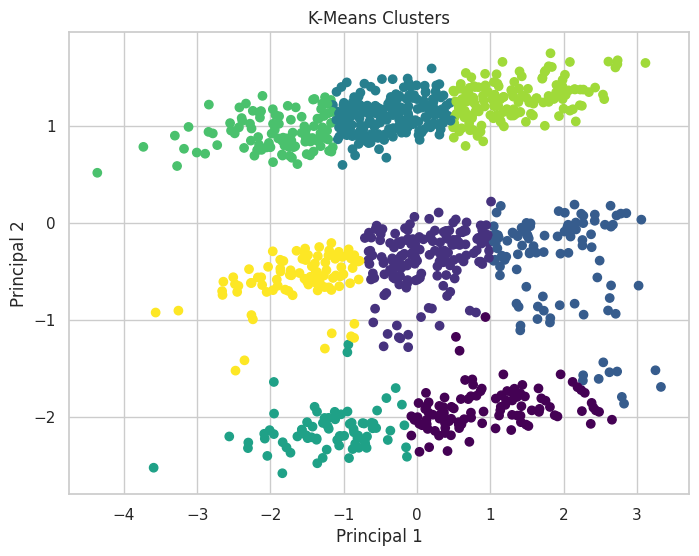

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca2[:, 0],X_pca2[:, 1], c=clusters2, cmap="viridis")

plt.title("K-Means Clusters")
plt.xlabel("Principal 1")
plt.ylabel("Principal 2")
plt.show()

| Aspect                   | K-Means (Without PCA)      | K-Means (With PCA)                       |
| ------------------------ | -------------------------- | ---------------------------------------- |
| Number of Features       | Original Features          | Reduced Features (PCA Components)        |
| Number of Clusters       | 4                          | 8                                        |
| Silhouette Score         | 0.127                      | 0.467                                    |
| Cluster Separation       | Weak                       | Strong                                   |
| Cluster Interpretability | Simpler and broader groups | More detailed and specific groups        |
| Data Dimensionality      | High                       | Reduced                                  |
| Pattern Discovery        | Limited                    | Better identification of hidden patterns |
| Overall Performance      | Lower                      | Higher                                   |


### Conclusion:
Applying PCA before K-Means significantly improved clustering performance. The Silhouette Score increased from 0.127 to 0.467, indicating better cluster cohesion and separation.